In [1]:
import os
from sklearn.model_selection import train_test_split

# Kaggle'dan indirdiğimiz klasörün yolu
DATASET_PATH = "Data/genres_original"
genres = ['blues', 'classical', 'country', 'disco', 'hiphop', 'jazz', 'metal', 'pop', 'reggae', 'rock']

file_paths = []
labels = []

# Klasörleri gezip tüm ses dosyalarının yollarını ve türlerini listeye ekliyoruz
for genre in genres:
    genre_dir = os.path.join(DATASET_PATH, genre)
    # Klasörün var olup olmadığını kontrol ediyoruz
    if os.path.exists(genre_dir):
        for filename in os.listdir(genre_dir):
            if filename.endswith('.wav'):
                file_paths.append(os.path.join(genre_dir, filename))
                labels.append(genre)

# Veri sızıntısını önlemek için ŞARKI BAZLI train/test ayrımı yapıyoruz
X_train, X_test, y_train, y_test = train_test_split(
    file_paths, labels, test_size=0.2, stratify=labels, random_state=42
)

print(f"Eğitim (Train) için ayrılan şarkı sayısı: {len(X_train)}")
print(f"Test (Test) için ayrılan şarkı sayısı: {len(X_test)}")

Eğitim (Train) için ayrılan şarkı sayısı: 800
Test (Test) için ayrılan şarkı sayısı: 200


In [1]:
import sys
!{sys.executable} -m pip install python-multipart uvicorn fastapi


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install librosa matplotlib scikit-learn numpy pandas

   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 20.6 MB/s eta 0:00:00
   ---------------------------------------- 0.0/1.0 MB ? eta -:--:--
   ---------------------------------------- 1.0/1.0 MB 20.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/38.1 MB ? eta -:--:--
   --- ------------------------------------ 3.7/38.1 MB 22.2 MB/s eta 0:00:02
   -------- ------------------------------- 7.9/38.1 MB 20.5 MB/s eta 0:00:02
   ------------ --------------------------- 11.5/38.1 MB 19.6 MB/s eta 0:00:02
   ---------------- ----------------------- 15.7/38.1 MB 19.6 MB/s eta 0:00:02
   -------------------- ------------------- 19.4/38.1 MB 19.2 MB/s eta 0:00:01
   ------------------------ --------------- 23.1/38.1 MB 18.7 MB/s eta 0:00:01
   --------------------------- ------------ 26.5/38.1 MB 18.4 MB/s eta 0:00:01
   ------------------------------- -------- 30.4/38.1 MB 18.5 MB/s eta 0:00:01
   -----

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


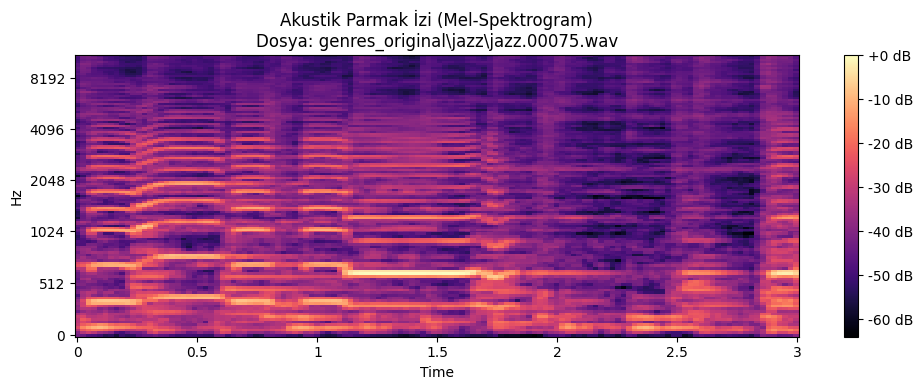

In [ ]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import numpy as np

def akustik_parmak_izi_ciz(dosya_yolu):
    # Raporuna uygun olarak: 22050 Hz örnekleme hızı ve 3 saniyelik bölütleme
    # Şimdilik görselleştirme için sadece ilk 3 saniyeyi (duration=3.0) yüklüyoruz
    y, sr = librosa.load(dosya_yolu, sr=22050, duration=3.0)
    
    # STFT ve Mel-Spektrogram dönüşümü (n_mels=128 ile 128 boyutlu frekans çözünürlüğü)
    mel_spect = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
    
    # Logaritmik insan işitme algısına uygun olması için genliği Desibel (dB) formatına çeviriyoruz
    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)
    
    # Matplotlib ile görselleştirme
    plt.figure(figsize=(10, 4))
    librosa.display.specshow(mel_spect_db, sr=sr, hop_length=512, x_axis='time', y_axis='mel')
    plt.colorbar(format='%+2.0f dB')
    plt.title(f'Akustik Parmak İzi (Mel-Spektrogram)\nDosya: {dosya_yolu.split("/")[-1]}')
    plt.tight_layout()
    plt.show()

# Eğitim setimizdeki ilk şarkıyı fonksiyona gönderip test edelim!
akustik_parmak_izi_ciz(X_train[0])

In [6]:
pip install tqdm

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [10]:
import librosa
import numpy as np
from tqdm import tqdm

# 3 saniyelik bir sesin içereceği örneklem (sample) sayısı: 22050 Hz * 3 saniye = 66150
SAMPLES_PER_SEGMENT = 22050 * 3
NUM_SEGMENTS = 10 # Her 30 saniyelik şarkıdan 10 parça çıkaracağız

def veri_isleme_ve_bolutleme(dosya_yollari, etiketler):
    X_veri = []
    y_veri = []
    
    # tqdm ile terminalde çok şık bir yükleme barı göreceğiz
    for i, dosya_yolu in enumerate(tqdm(dosya_yollari, desc="Sesler İşleniyor")):
        try:
            # Şarkının tamamını yüklüyoruz
            y, sr = librosa.load(dosya_yolu, sr=22050)
            
            # Şarkıyı 10 parçaya bölüyoruz
            for s in range(NUM_SEGMENTS):
                baslangic = SAMPLES_PER_SEGMENT * s
                bitis = baslangic + SAMPLES_PER_SEGMENT
                
                # 3 saniyelik dilimi (segment) alıyoruz
                y_dilim = y[baslangic:bitis]
                
                # Eğer dilim tam 3 saniye uzunluğundaysa işleme al (bazı dosyaların sonu eksik olabilir, hata almamak için)
                if len(y_dilim) == SAMPLES_PER_SEGMENT:
                    # Mel-Spektrogram dönüşümü
                    mel_spect = librosa.feature.melspectrogram(y=y_dilim, sr=sr, n_fft=2048, hop_length=512, n_mels=128)
                    
                    # Desibel (dB) ölçeğine çevirme
                    mel_spect_db = librosa.power_to_db(mel_spect, ref=np.max)
                    
                    # CNN'e verebilmek için sonuna bir kanal boyutu ekliyoruz (128, 130) -> (128, 130, 1)
                    # Bu sayede model bunu tek kanallı (siyah-beyaz) bir resim gibi görecek
                    X_veri.append(mel_spect_db[..., np.newaxis])
                    y_veri.append(etiketler[i])
                    
        except Exception as e:
            # Nadiren de olsa bozuk bir ses dosyası çıkarsa kodu patlatmadan uyarı versin
            print(f"\nHata oluşan dosya: {dosya_yolu} - Hata: {e}")
            
    return np.array(X_veri), np.array(y_veri)

print("--- Eğitim Seti (Train) İşleniyor ---")
X_train_islenmis, y_train_islenmis = veri_isleme_ve_bolutleme(X_train, y_train)

print("\n--- Test Seti (Test) İşleniyor ---")
X_test_islenmis, y_test_islenmis = veri_isleme_ve_bolutleme(X_test, y_test)

print("\n!!! İŞLEM TAMAMLANDI !!!")
print(f"Eğitilecek Matris Boyutu: {X_train_islenmis.shape}")
print(f"Test Edilecek Matris Boyutu: {X_test_islenmis.shape}")

--- Eğitim Seti (Train) İşleniyor ---


Sesler İşleniyor:  81%|████████  | 646/800 [00:43<00:10, 14.69it/s]C:\Users\kerem\AppData\Local\Temp\ipykernel_2796\3947821635.py:17: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(dosya_yolu, sr=22050)
Sesler İşleniyor:  81%|████████  | 649/800 [00:43<00:08, 17.04it/s]


Hata oluşan dosya: Data/genres_original\jazz\jazz.00054.wav - Hata: 


Sesler İşleniyor: 100%|██████████| 800/800 [00:53<00:00, 14.88it/s]



--- Test Seti (Test) İşleniyor ---


Sesler İşleniyor: 100%|██████████| 200/200 [00:14<00:00, 14.03it/s]


!!! İŞLEM TAMAMLANDI !!!
Eğitilecek Matris Boyutu: (7981, 128, 130, 1)
Test Edilecek Matris Boyutu: (2000, 128, 130, 1)


In [11]:
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

# 1. Metinleri (string) sayılara dönüştürme (Örn: 'blues' -> 0, 'classical' -> 1)
label_encoder = LabelEncoder()

# fit_transform ile hem sınıfları öğreniyor hem de dönüştürüyor
y_train_sayisal = label_encoder.fit_transform(y_train_islenmis)

# Test setinde sadece transform kullanıyoruz ki eğitimde görmediği yeni bir sınıf üretmesin
y_test_sayisal = label_encoder.transform(y_test_islenmis)

# 2. Sayıları One-Hot Encoding formatına çevirme
num_classes = len(label_encoder.classes_)
y_train_encoded = to_categorical(y_train_sayisal, num_classes)
y_test_encoded = to_categorical(y_test_sayisal, num_classes)

print("--- Encoding İşlemi Başarıyla Tamamlandı ---")
print(f"Toplam sınıf sayısı: {num_classes}")
print(f"Sınıflar: {label_encoder.classes_}")
print(f"y_train_encoded boyutu: {y_train_encoded.shape}")
print(f"Test amaçlı ilk etiketin (y_train_encoded[0]) görünümü: \n{y_train_encoded[0]}")

--- Encoding İşlemi Başarıyla Tamamlandı ---
Toplam sınıf sayısı: 10
Sınıflar: ['blues' 'classical' 'country' 'disco' 'hiphop' 'jazz' 'metal' 'pop'
 'reggae' 'rock']
y_train_encoded boyutu: (7981, 10)
Test amaçlı ilk etiketin (y_train_encoded[0]) görünümü: 
[0. 0. 0. 0. 0. 1. 0. 0. 0. 0.]


In [9]:
pip install tensorflow

  Using cached mdurl-0.1.2-py3-none-any.whl.metadata (1.6 kB)
   ---------------------------------------- 0.0/351.2 MB ? eta -:--:--
   - -------------------------------------- 13.1/351.2 MB 71.5 MB/s eta 0:00:05
   -- ------------------------------------- 20.2/351.2 MB 51.6 MB/s eta 0:00:07
   ---- ----------------------------------- 35.4/351.2 MB 58.0 MB/s eta 0:00:06
   ----- ---------------------------------- 51.6/351.2 MB 63.5 MB/s eta 0:00:05
   ------- -------------------------------- 68.2/351.2 MB 67.4 MB/s eta 0:00:05
   --------- ------------------------------ 85.2/351.2 MB 70.1 MB/s eta 0:00:04
   ----------- --------------------------- 101.2/351.2 MB 71.2 MB/s eta 0:00:04
   ------------- ------------------------- 119.8/351.2 MB 72.9 MB/s eta 0:00:04
   --------------- ----------------------- 138.7/351.2 MB 74.5 MB/s eta 0:00:03
   ---------------- ---------------------- 152.8/351.2 MB 73.9 MB/s eta 0:00:03
   ------------------- ------------------- 171.4/351.2 MB 74.7 MB/s

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.

[notice] A new release of pip is available: 25.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Raporunda detaylandırdığın CNN Mimarisi
model = Sequential([
    # 1. Evrişim ve Havuzlama Katmanı (Görüntüdeki düşük seviyeli özellikleri yakalar)
    Conv2D(32, (3, 3), activation='relu', input_shape=(128, 130, 1)),
    MaxPooling2D((2, 2)),
    Dropout(0.2), # Aşırı öğrenmeyi (overfitting) önlemek için

    # 2. Evrişim ve Havuzlama Katmanı
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # 3. Evrişim ve Havuzlama Katmanı (Daha karmaşık özellikleri öğrenir)
    Conv2D(128, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Dropout(0.2),

    # Tam Bağlantılı (Fully Connected) Katmanlara Geçiş
    Flatten(),

    # İleride Öneri Sistemi için kullanacağımız 256 Boyutlu Embedding Katmanı!
    # Burası şarkının akustik parmak izini temsil eden o sayısal özeti çıkaracak.
    Dense(256, activation='relu', name='feature_extractor_layer'),
    Dropout(0.3),

    # Sınıflandırma Katmanı (10 farklı müzik türü olduğu için Softmax kullanıyoruz)
    Dense(10, activation='softmax', name='classification_layer')
])

# Modelin derlenmesi (Raporda belirttiğin gibi Categorical Cross-Entropy ile)
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Modelin anatomisini ekrana yazdıralım
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 126, 128, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 63, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 61, 62, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 30, 31, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 29, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ feature_extractor_layer (Dense) │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ classification_layer (Dense)    │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,518,026 (24.86 MB)

 Trainable params: 6,518,026 (24.86 MB)

 Non-trainable params: 0 (0.00 B)

In [17]:
# Modelin normalize edilmiş taze verilerle yeniden eğitimi
history = model.fit(
    X_train_norm, y_train_encoded,
    epochs=30,
    batch_size=32,
    validation_data=(X_test_norm, y_test_encoded)
)

Epoch 1/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 95s 371ms/step - accuracy: 0.2708 - loss: 1.9637 - val_accuracy: 0.4780 - val_loss: 1.4941
Epoch 2/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 93s 372ms/step - accuracy: 0.5098 - loss: 1.3542 - val_accuracy: 0.5910 - val_loss: 1.2432
Epoch 3/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 95s 379ms/step - accuracy: 0.5914 - loss: 1.1318 - val_accuracy: 0.6335 - val_loss: 1.1069
Epoch 4/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 91s 363ms/step - accuracy: 0.6497 - loss: 1.0038 - val_accuracy: 0.6265 - val_loss: 1.1105
Epoch 5/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 97s 390ms/step - accuracy: 0.6832 - loss: 0.9262 - val_accuracy: 0.6350 - val_loss: 1.1003
Epoch 6/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 86s 343ms/step - accuracy: 0.7124 - loss: 0.8268 - val_accuracy: 0.6430 - val_loss: 1.0905
Epoch 7/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 333ms/step - accuracy: 0.7461 - loss: 0.7231 - val_accuracy: 0.6500 - val_loss: 1.0774
Epoch 8/30
250/250 ━━━━━━━━━━━━━━━━━━━━ 83s 331ms/step - accuracy: 0.7705 - loss: 0

In [14]:
import numpy as np

# 1. Eğitim setinden minimum ve maksimum değerleri buluyoruz (Veri Sızıntısını önlemek için sadece train!)
min_val = np.min(X_train_islenmis)
max_val = np.max(X_train_islenmis)

print(f"Orijinal Değer Aralığı: Min={min_val:.2f} dB, Max={max_val:.2f} dB")

# 2. Min-Max Normalizasyonu (Verileri 0 ile 1 arasına sıkıştırıyoruz)
X_train_norm = (X_train_islenmis - min_val) / (max_val - min_val)

# Test setini de EĞİTİM setinin min/max değerleriyle normalize ediyoruz
X_test_norm = (X_test_islenmis - min_val) / (max_val - min_val)

print(f"Yeni Değer Aralığı: Min={np.min(X_train_norm):.2f}, Max={np.max(X_train_norm):.2f}")
print("--- Normalizasyon Başarılı ---")

Orijinal Değer Aralığı: Min=-80.00 dB, Max=0.00 dB
Yeni Değer Aralığı: Min=0.00, Max=1.00
--- Normalizasyon Başarılı ---


63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 79ms/step


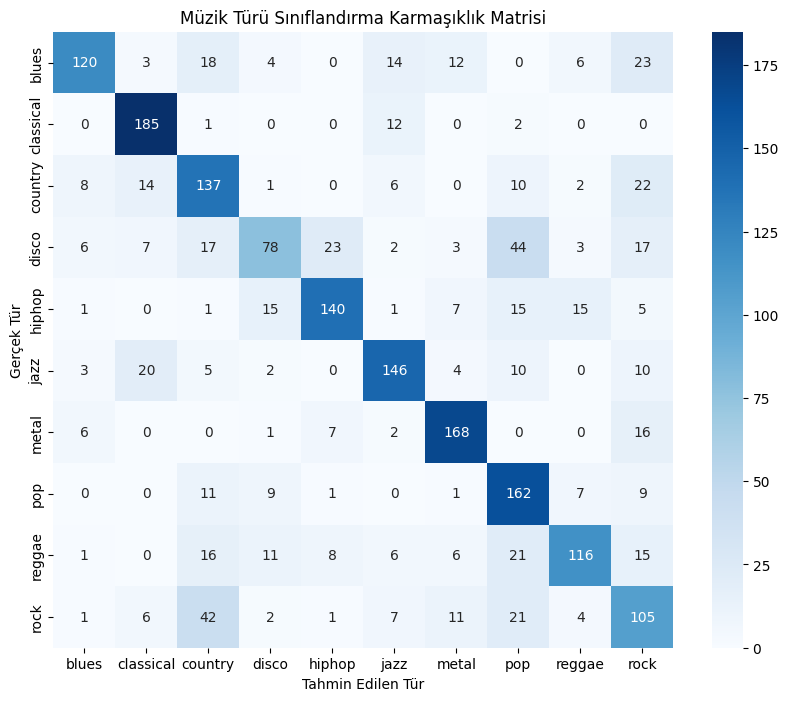

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Test verisi üzerinden tahminlerimizi alalım
y_pred = model.predict(X_test_norm)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test_encoded, axis=1)

# Karmaşıklık Matrisi oluşturma 
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=label_encoder.classes_, 
            yticklabels=label_encoder.classes_)
plt.xlabel('Tahmin Edilen Tür')
plt.ylabel('Gerçek Tür')
plt.title('Müzik Türü Sınıflandırma Karmaşıklık Matrisi')
plt.show()

In [ ]:
import IPython.display as ipd
import random

# Tahminlerin yanlış olduğu indeksleri bulalım
hatali_indeksler = np.where(y_pred_classes != y_true_classes)[0]

# Rastgele bir hatalı örnek seçelim
secilen_hata_idx = random.choice(hatali_indeksler)

# Bilgileri alalım
gercek_tur = label_encoder.inverse_transform([y_true_classes[secilen_hata_idx]])[0]
tahmin_edilen_tur = label_encoder.inverse_transform([y_pred_classes[secilen_hata_idx]])[0]

print(f"--- Hata Analizi ---")
print(f"Gerçek Tür: {gercek_tur}")
print(f"Modelin Tahmini: {tahmin_edilen_tur}")
print(f"Güven Oranı (Probability): %{100*np.max(y_pred[secilen_hata_idx]):.2f}")

# O 3 saniyelik ses parçasını çalmak için orijinal veriden o kısmı çekelim
# Not: Normalizasyon yaptığımız için X_test_norm içindeki veriyi değil, 
# orijinal ses sinyalini (y_dilim) temsil eden veriyi dinlemeliyiz.
# Test setindeki dosya yolunu bulup o parçayı tekrar yüklüyoruz.

sarki_yolu = X_test_paths[secilen_hata_idx // 10] # Hangi orijinal dosyadan geldiğini buluyoruz
segment_no = secilen_hata_idx % 10
y, sr = librosa.load(sarki_yolu, sr=22050, offset=segment_no*3, duration=3)

print(f"\nŞu an çalınan parça: {sarki_yolu.split('/')[-1]} (Parça {segment_no+1})")
ipd.Audio(y, rate=sr)

--- Hata Analizi ---
Gerçek Tür: blues
Modelin Tahmini: rock
Güven Oranı (Probability): %87.61


NameError: name 'X_test_paths' is not defined

In [20]:
import IPython.display as ipd

# Değişken ismini kontrol ederek (X_test veya X_test_paths hangisini kullandıysan ona göre)
# Eğer yukarıda X_test_paths kullandıysan öyle kalsın, yoksa X_test yapalım:
test_yollari = X_test_paths if 'X_test_paths' in locals() else X_test

sarki_yolu = test_yollari[secilen_hata_idx // 10] 
segment_no = secilen_hata_idx % 10

# Şarkıyı yükle (Raporundaki 22050 Hz standardıyla)
y, sr = librosa.load(sarki_yolu, sr=22050, offset=segment_no*3, duration=3)

print(f"--- Dinleme Paneli ---")
print(f"Dosya: {sarki_yolu.split(os.sep)[-1]} | Parça No: {segment_no+1}")
print(f"Gerçekte: {gercek_tur} iken Model %{100*np.max(y_pred[secilen_hata_idx]):.2f} ihtimalle {tahmin_edilen_tur} demiş.")

ipd.Audio(y, rate=sr)

--- Dinleme Paneli ---
Dosya: blues.00074.wav | Parça No: 6
Gerçekte: blues iken Model %87.61 ihtimalle rock demiş.


In [22]:
from tensorflow.keras.models import Model
import tensorflow as tf

# 1. Modeli sembolik olarak değil, bir kez sahte veriyle tetikleyerek girişini tescilliyoruz
input_shape = (1, 128, 130, 1) # (Batch_size, Height, Width, Channels)
model(tf.zeros(input_shape)) # Modeli bir kez "boş" veriyle çalıştırıyoruz

# 2. Şimdi Feature Extractor'ı tekrar kurmayı deneyelim
feature_extractor = Model(inputs=model.inputs, 
                          outputs=model.get_layer('feature_extractor_layer').output)

# 3. Tüm test verilerimizi (2000 segment) 256 boyutlu vektörlere dönüştürelim
print("Şarkıların akustik parmak izleri çıkarılıyor...")
all_embeddings = feature_extractor.predict(X_test_norm)

# Öneri fonksiyonu kodunu aşağıya tekrar ekliyorum (Değişken ismi tutsun diye)
def benzer_sarki_oner(sarki_index, top_n=5):
    query_vector = all_embeddings[sarki_index].reshape(1, -1)
    similarities = cosine_similarity(query_vector, all_embeddings)[0]
    benzer_indeksler = np.argsort(similarities)[::-1][1:top_n+1]
    
    gercek_tur = y_test_islenmis[sarki_index]
    print(f"Sorgulanan Şarkı Türü: {gercek_tur.upper()}")
    print(f"{'-'*30}")
    
    for i in benzer_indeksler:
        benzer_tur = y_test_islenmis[i]
        skor = similarities[i]
        print(f"Öneri: {benzer_tur.ljust(10)} | Benzerlik Skoru: {skor:.4f}")

# TEST: Rastgele bir şarkı seçip önerileri görelim
import random
test_idx = random.randint(0, len(X_test_norm)-1)
benzer_sarki_oner(test_idx)

Şarkıların akustik parmak izleri çıkarılıyor...
63/63 ━━━━━━━━━━━━━━━━━━━━ 5s 80ms/step
Sorgulanan Şarkı Türü: CLASSICAL
------------------------------
Öneri: classical  | Benzerlik Skoru: 0.9637
Öneri: classical  | Benzerlik Skoru: 0.9584
Öneri: classical  | Benzerlik Skoru: 0.9564
Öneri: classical  | Benzerlik Skoru: 0.9423
Öneri: classical  | Benzerlik Skoru: 0.9356


In [23]:
import IPython.display as ipd

def sarki_oynat_ve_oner(sarki_index, top_n=5):
    # 1. Sorgulanan şarkıyı analiz et ve göster
    query_vector = all_embeddings[sarki_index].reshape(1, -1)
    similarities = cosine_similarity(query_vector, all_embeddings)[0]
    benzer_indeksler = np.argsort(similarities)[::-1][:top_n+1] # Kendisi dahil ilk 6
    
    test_yollari = X_test_paths if 'X_test_paths' in locals() else X_test
    
    print(f"🚀 SORGULANAN ŞARKI: {y_test_islenmis[sarki_index].upper()}")
    
    for i, idx in enumerate(benzer_indeksler):
        # Şarkı bilgilerini al
        sarki_yolu = test_yollari[idx // 10]
        segment_no = idx % 10
        tur = y_test_islenmis[idx]
        skor = similarities[idx]
        
        # Sesi yükle (3 saniyelik parça) [cite: 315]
        y, sr = librosa.load(sarki_yolu, sr=22050, offset=segment_no*3, duration=3)
        
        if i == 0:
            print(f"\n🎵 ŞU AN DİNLEDİĞİNİZ PARÇA:")
            ipd.display(ipd.Audio(y, rate=sr))
            print(f"{'='*50}\n🔥 BUNLARI DA SEVEBİLİRSİNİZ:")
        else:
            print(f"\n{i}. Öneri | Tür: {tur.ljust(10)} | Benzerlik Skoru: {skor:.4f}")
            ipd.display(ipd.Audio(y, rate=sr))

# Hadi taze bir test patlatalım!
test_idx = random.randint(0, len(X_test_norm)-1)
sarki_oynat_ve_oner(test_idx)

🚀 SORGULANAN ŞARKI: JAZZ

🎵 ŞU AN DİNLEDİĞİNİZ PARÇA:


🔥 BUNLARI DA SEVEBİLİRSİNİZ:

1. Öneri | Tür: jazz       | Benzerlik Skoru: 0.9065



2. Öneri | Tür: jazz       | Benzerlik Skoru: 0.8512



3. Öneri | Tür: jazz       | Benzerlik Skoru: 0.8195



4. Öneri | Tür: jazz       | Benzerlik Skoru: 0.8178



5. Öneri | Tür: jazz       | Benzerlik Skoru: 0.8134


In [ ]:
import IPython.display as ipd
import pandas as pd

def profesyonel_sarki_oner(secilen_segment_idx, top_n=5):
    # 1. Seçilen segmentin vektörü
    query_vector = all_embeddings[secilen_segment_idx].reshape(1, -1)
    
    # 2. Tüm segmentlerle benzerliği hesapla
    similarities = cosine_similarity(query_vector, all_embeddings)[0]
    
    # 3. Sonuçları bir DataFrame'e dökerek gruplayalım
    test_yollari = X_test_paths if 'X_test_paths' in locals() else X_test
    
    df_sonuclar = pd.DataFrame({
        'dosya_yolu': [test_yollari[i // 10] for i in range(len(similarities))],
        'tur': y_test_islenmis,
        'benzerlik': similarities
    })
    
    # Sorgulanan şarkının kendisini sonuçlardan çıkaralım
    sorgulanan_yol = test_yollari[secilen_segment_idx // 10]
    df_sonuclar = df_sonuclar[df_sonuclar['dosya_yolu'] != sorgulanan_yol]
    
    # 4. Şarkı bazlı grupla ve ortalama benzerliği al (Distinct Şarkılar)
    # Raporundaki "Açısal Yakınlık" mantığını şarkı geneline yayıyoruz [cite: 559]
    oneri_listesi = df_sonuclar.groupby('dosya_yolu').agg({
        'benzerlik': 'mean',
        'tur': 'first'
    }).sort_values(by='benzerlik', ascending=False).head(top_n)
    
    print(f"🎵 SORGULANAN ŞARKI: {y_test_islenmis[secilen_segment_idx].upper()}")
    print(f"📍 Dosya: {sorgulanan_yol.split(os.sep)[-1]}")
    
    # Sorgulanan şarkının TAMAMINI (30 sn) dinlet
    y_q, sr_q = librosa.load(sorgulanan_yol, sr=22050)
    ipd.display(ipd.Audio(y_q, rate=sr_q))
    
    print(f"\n{'='*60}")
    print(f"🔥 SİZİN İÇİN SEÇTİĞİMİZ DISTINCT ŞARKILAR (30 SANİYE):")
    print(f"{'='*60}")
    
    for path, row in oneri_listesi.iterrows():
        print(f"\n📌 Tür: {row['tur'].upper()} | Ortalama Benzerlik: {row['benzerlik']:.4f}")
        print(f"📂 Dosya: {path.split(os.sep)[-1]}")
        
        # Önerilen şarkının TAMAMINI (30 sn) yükle ve oynat
        y_r, sr_r = librosa.load(path, sr=22050)
        ipd.display(ipd.Audio(y_r, rate=sr_r))

# TEST ET: Artık 3 saniye değil, gerçek bir müzik keyfi!
test_idx = random.randint(0, len(X_test_norm)-1)
profesyonel_sarki_oner(test_idx)